In [1]:
import numpy
import matplotlib.pyplot as plt
import torch
import torchvision
import torch.cuda
import deepRD.tools.trajectoryTools as trajectoryTools
import csv
from torchvision.transforms import ToTensor
from torch import nn
from torch.utils.data import DataLoader
from sklearn.neighbors import KernelDensity
from scipy.stats import wasserstein_distance_nd
from annealing import Annealer

In [121]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [113]:
#CHANGES

class VarAutoencoder_128(nn.Module):

    def __init__(self, latentDims, loadPretrained, conditionedOn):
        super().__init__()
        self.conditionedOn = conditionedOn
        self.latentDims = latentDims
        self.conditionDims = self.getConditionDims()
        self.encoder = nn.Sequential(
            nn.Linear(3+self.conditionDims, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 40),
            nn.ReLU(),
            nn.Linear(40, 20),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(self.latentDims+self.conditionDims, 20),
            nn.ReLU(),
            nn.Linear(20, 40),
            nn.ReLU(),
            nn.Linear(40, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )
        self.linear1 = nn.Linear(20, self.latentDims)
        self.linear2 = nn.Linear(20, self.latentDims)
        self.G = torch.distributions.Normal(0, 1)
        self.losses = []
        
        if loadPretrained==None:
            print('Untrained model initialized. CondtionedVars: ', conditionedOn)
        else:
            print('Loading pretrained model: ' + loadPretrained)
            self.load_state_dict(torch.load(loadPretrained))
            print('Model parameters loaded.')

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + std*self.G.sample(mu.shape)

    def sample(self, label, num_samples=1):
        
        mean = 0
        std = 1

        if label.dim()==1:
            label = label.unsqueeze(0)
        samples = torch.normal(mean, std, (num_samples,self.latentDims))
        z_cond = torch.cat((samples, label), dim=1)
        return self.decoder(z_cond)

    def forward(self, x, y, returnLatent=False):
        x_cond = torch.cat((x,y), dim=1)
        x = self.encoder(x_cond)
        mu = self.linear1(x)
        logvar = self.linear2(x)
        z = self.reparametrize(mu, logvar)
        z_cond = torch.cat((z, y), dim=1)
        output = self.decoder(z_cond)
        if returnLatent==True:
            return output, mu, logvar, z
        return output, mu, logvar

    def getConditionDims(self):    
        if self.conditionedOn=="piri":
            return 6
        elif self.conditionedOn=="piririm":
            return 9
        elif self.conditionedOn=="pipimri":
            return 9
        elif self.conditionedOn=="piririmpim":
            return 12

In [114]:
class VarAutoencoder_S(nn.Module):

    def __init__(self, latentDims, loadPretrained, conditionedOn):
        super().__init__()
        self.conditionedOn = conditionedOn
        self.latentDims = latentDims
        self.conditionDims = self.getConditionDims()
        self.encoder = nn.Sequential(
            nn.Linear(3+self.conditionDims, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(self.latentDims+self.conditionDims, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )
        self.linear1 = nn.Linear(32, self.latentDims)
        self.linear2 = nn.Linear(32, self.latentDims)
        self.G = torch.distributions.Normal(0, 1)
        self.losses = []
        
        if loadPretrained==None:
            print('Untrained model initialized. S. CondtionedVars: ', conditionedOn)
        else:
            print('Loading pretrained model: ' + loadPretrained)
            self.load_state_dict(torch.load(loadPretrained))
            print('Model parameters loaded.')

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + std*self.G.sample(mu.shape)

    def sample(self, label, num_samples=1):
        
        mean = 0
        std = 1.2

        if label.dim()==1:
            label = label.unsqueeze(0)
        samples = torch.normal(mean, std, (num_samples,self.latentDims))
        z_cond = torch.cat((samples, label), dim=1)
        return self.decoder(z_cond)

    def forward(self, x, y, returnLatent=False):
        x_cond = torch.cat((x,y), dim=1)
        x = self.encoder(x_cond)
        mu = self.linear1(x)
        logvar = self.linear2(x)
        z = self.reparametrize(mu, logvar)
        z_cond = torch.cat((z, y), dim=1)
        output = self.decoder(z_cond)
        if returnLatent==True:
            return output, mu, logvar, z
        return output, mu, logvar

    def getConditionDims(self):    
        if self.conditionedOn=="piri":
            return 6
        elif self.conditionedOn=="piririm":
            return 9
        elif self.conditionedOn=="piripim":
            return 9
        elif self.conditionedOn=="piririmpim":
            return 12


class VarAutoencoder_SE(nn.Module):

    def __init__(self, latentDims, loadPretrained, conditionedOn):
        super().__init__()
        self.conditionedOn = conditionedOn
        self.latentDims = latentDims
        self.conditionDims = self.getConditionDims()
        self.encoder = nn.Sequential(
            nn.Linear(3+self.conditionDims, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(self.latentDims+self.conditionDims, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )
        self.linear1 = nn.Linear(32, self.latentDims)
        self.linear2 = nn.Linear(32, self.latentDims)
        self.G = torch.distributions.Normal(0, 1)
        self.losses = []
        
        if loadPretrained==None:
            print('Untrained model initialized. S. CondtionedVars: ', conditionedOn)
        else:
            print('Loading pretrained model: ' + loadPretrained)
            self.load_state_dict(torch.load(loadPretrained))
            print('Model parameters loaded.')

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + std*self.G.sample(mu.shape).to(device)

    def sample(self, label, num_samples=1):
        
        mean = 0
        std = 1.25

        if label.dim()==1:
            label = label.unsqueeze(0)
        samples = torch.normal(mean, std, (num_samples,self.latentDims))
        z_cond = torch.cat((samples, label), dim=1)
        return self.decoder(z_cond)

    def forward(self, x, y, returnLatent=False):
        x_cond = torch.cat((x,y), dim=1)
        x = self.encoder(x_cond)
        mu = self.linear1(x)
        logvar = self.linear2(x)
        z = self.reparametrize(mu, logvar)
        z_cond = torch.cat((z, y), dim=1)
        output = self.decoder(z_cond)
        if returnLatent==True:
            return output, mu, logvar, z
        return output, mu, logvar

    def getConditionDims(self):    
        if self.conditionedOn=="piri":
            return 6
        elif self.conditionedOn=="piririm":
            return 9
        elif self.conditionedOn=="piripim":
            return 9
        elif self.conditionedOn=="piririmpim":
            return 12

class VarAutoencoder_SEE(nn.Module):

    def __init__(self, latentDims, loadPretrained, conditionedOn):
        super().__init__()
        self.conditionedOn = conditionedOn
        self.latentDims = latentDims
        self.conditionDims = self.getConditionDims()
        self.encoder = nn.Sequential(
            nn.Linear(3+self.conditionDims, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(self.latentDims+self.conditionDims, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 3)
        )
        self.linear1 = nn.Linear(32, self.latentDims)
        self.linear2 = nn.Linear(32, self.latentDims)
        self.G = torch.distributions.Normal(0, 1)
        self.losses = []
        
        if loadPretrained==None:
            print('Untrained model initialized. S. CondtionedVars: ', conditionedOn)
        else:
            print('Loading pretrained model: ' + loadPretrained)
            self.load_state_dict(torch.load(loadPretrained))
            print('Model parameters loaded.')

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + std*self.G.sample(mu.shape)

    def sample(self, label, num_samples=1):
        
        mean = 0
        std = 1.2

        if label.dim()==1:
            label = label.unsqueeze(0)
        samples = torch.normal(mean, std, (num_samples,self.latentDims))
        z_cond = torch.cat((samples, label), dim=1)
        return self.decoder(z_cond)

    def forward(self, x, y, returnLatent=False):
        x_cond = torch.cat((x,y), dim=1)
        x = self.encoder(x_cond)
        mu = self.linear1(x)
        logvar = self.linear2(x)
        z = self.reparametrize(mu, logvar)
        z_cond = torch.cat((z, y), dim=1)
        output = self.decoder(z_cond)
        if returnLatent==True:
            return output, mu, logvar, z
        return output, mu, logvar

    def getConditionDims(self):    
        if self.conditionedOn=="piri":
            return 6
        elif self.conditionedOn=="piririm":
            return 9
        elif self.conditionedOn=="piripim":
            return 9
        elif self.conditionedOn=="piririmpim":
            return 12

In [115]:
# Defining loss functions 

loss_1 = nn.MSELoss()
def loss_2(mu, logvar):
    return torch.mean(-0.5 * torch.sum(1 + logvar - mu ** 2 - torch.exp(logvar), dim = 1), dim = 0)#.sum()

In [116]:
def modelTraining(data_loader, epochs, beta1, beta2, test_data_loader):
    
    return_reconstructions = False
    losses = []
    losses_EP = []
    r_norms = None
    r_new = None

    annealing_period = 10
    annealing_agent = Annealer(annealing_period, shape='logistic', cyclical=True, disable=False) # instantiating annealing agent
    
    for epoch in range(epochs):
        VAE.train()
        r_epoch = None
        
        # Saving loss both per-batch and total (average) loss
        val_loss = 0
        total_loss = 0
        total_l1 = 0
        total_l2 = 0
        bc = 0 # counting batches to calculate per-batch error
        
        

        # At the start of epoch, evaluate validation error.
        for (image_t, label_t) in test_data_loader:
            bc += 1
            
            image_t, label_t = image_t.to(device), label_t.to(device)
            
            reconstruction_t, mu_t, logvar_t = VAE(image_t, label_t)
            val_loss += loss_1(reconstruction_t, image_t).item() # MSE loss only on validation set

        val_loss /= bc # recover average per-batch loss
        bc = 0
        
        for (image, label) in data_loader:
            bc += 1
            
            image, label = image.to(device), label.to(device)
            
            # Feed through the network
            reconstruction, mu, logvar = VAE(image, label)
            # Calculate loss function
            l1 = loss_1(reconstruction, image)
            l2 = loss_2(mu, logvar)
            l2 = annealing_agent(l2)

            #print(annealing_agent.slope(), l2.item())
            loss = beta1*l1 + beta2*l2
            losses.append([loss.item(), beta1*l1.item(), beta2*l2.item(), val_loss])
            
            total_loss += loss.item()
            total_l1 += l1.item()
            total_l2 += l2.item()
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


            if return_reconstructions and epoch==epochs-1:
                with torch.no_grad():
                    if r_epoch is None:
                        r_epoch = reconstruction
                    else:
                        r_epoch = torch.cat( (r_epoch, reconstruction), dim=0)
                        
        annealing_agent.step()
        losses_EP.append([total_l1/bc, total_l2*beta2/bc, total_loss/bc, val_loss])
        print(f'E{epoch+1}, MSE: {round(losses_EP[-1][0]*1000,4)}, KLD: {round(losses_EP[-1][1]*1000,4)}, TOT: {round(losses_EP[-1][2]*1000,4)} V: {round(losses_EP[-1][3]*1000,4)}')
    return r_epoch, losses, losses_EP

In [117]:
# Datasets directory
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/bistable/boxsize5/benchmark/"

# Total no. of datasets
n_datasets = 20
train_split = 0.8

# Sample simulation files randomly
fnums = numpy.random.choice(2500, n_datasets)
print(fnums)
dataset = None

for f_num in fnums:
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)).unsqueeze(0)
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = torch.cat((dataset, ds), dim=0)

# Dataset - training data
dataset.shape
print(torch.mean(dataset, dim=(0,1)))

[ 419 1515 1492  419  399 1995 1506  814 1100  803 1744 1326  335  294
 2223 2324 1719  218 1964 1589]
tensor([ 4.9997e+02, -7.6024e-02,  6.6365e-02, -4.1085e-02, -2.3006e-03,
         1.6110e-04,  1.0061e-03,  1.0000e+00,  1.8887e-05,  1.2257e-04,
        -6.6883e-05])


In [118]:
# CHANGES
# Select conditioned variables: piri - [r_n, v_n], piririm - [v_n, r_n, r_n-1], 
#$piripim - [v_n, r_n, v_n-1], piririmpim - [v_n, r_n, r_n-1, v_n-1]
conditionedOn = 'piri'

# Reforming data for input ; datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim total

# Number of datasets for training
n_datasets = dataset.shape[0]

# Extracting desired vectors from dataset

r_aux = dataset[:, :, -3:] # r_n
r_nxt = torch.roll(r_aux, -1, 1) # r_n+1
r_prev = torch.roll(r_aux, 1, 1) # r_n-1
v = dataset[:, :, 4:7] # v_n
v_prev = torch.roll(v, 1, 1) # v_n-1


# Cut out first & last datapoint for consistency
r_aux = r_aux[:, 1:-1].flatten(end_dim=1)
r_nxt = r_nxt[:, 1:-1].flatten(end_dim=1)
r_prev = r_prev[:, 1:-1].flatten(end_dim=1)
v = v[:, 1:-1].flatten(end_dim=1)
v_prev = v_prev[:, 1:-1].flatten(end_dim=1)


if conditionedOn == 'piri':
    conditionalVars = torch.cat((r_aux, v), dim = 1) # r_n + v_n
elif conditionedOn == 'piririm':
    conditionalVars = torch.cat((v, r_aux, r_prev), dim = 1) # v_n + r_n + r_n-1
elif conditionedOn == 'pipimri':
    conditionalVars = torch.cat((v, v_prev, r_aux), dim = 1)
elif conditionedOn == 'piririmpim':
    conditionalVars = torch.cat((v, r_aux, r_prev, v_prev), dim = 1)
else:
    print('Invalid model type')



# Split data: first 20% test, remaining 80% test.
split_ind = int(0.2*len(r_aux))

# Rebuild data for model Input: R_n+1 (3), condition: r_n, velocity_n (6)
test_data = torch.utils.data.TensorDataset(r_nxt[:split_ind], conditionalVars[:split_ind])
data = torch.utils.data.TensorDataset(r_nxt[split_ind:], conditionalVars[split_ind:])

r_aux.shape, r_nxt.shape, v.shape, conditionalVars.shape, len(test_data), len(data), #conditionalVars[:2] #, r_aux[:3], r_nxt[:3], v[:3], r_v[:3]z

(torch.Size([199960, 3]),
 torch.Size([199960, 3]),
 torch.Size([199960, 3]),
 torch.Size([199960, 6]),
 39992,
 159968)

In [119]:
# CHANGES 
# Model weights file directory or None if you want to load Untrained

loadPretrained = None
#loadPretrained = 'modelWeights/' + 'model_state_' + conditionedOn + '_E8pm_5.pt'


initialize_model = True
if initialize_model:
    #VAE = VarAutoencoder_128(2, loadPretrained, conditionedOn)
    VAE = VarAutoencoder_SE(8, loadPretrained, conditionedOn)
    #VAE = VarAutoencoder_S(6, loadPretrained, conditionedOn)
    VAE = VAE.to(device)
    
    f = open("modelLosses/losses_nb.csv", "w")
    f.truncate()
    f.close()
    
else:
    print('Continuing with existing model.')

# Training parameters
n_epochs = 20
batch_size = 32
# beta1 - MSE Loss, beta2 - KL Div Loss Maximum Value.
beta1 = 1 #10
beta2 = 1e-5 #5e-5#2e-5

data_loader = DataLoader(data, batch_size=batch_size, shuffle=True)
test_data_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)


# Optimizer parameters:
learning_rate = 1e-4
weight_decay = 0 #1e-6 #1e-8

optimizer = torch.optim.Adam(VAE.parameters(),
                             lr = learning_rate,
                             weight_decay = weight_decay)

Untrained model initialized. S. CondtionedVars:  piri


In [120]:
train = True

if train:
    print(device)
    # Training data is used for fitting
    _, losses, epoch_losses = modelTraining(data_loader, n_epochs, beta1, beta2, test_data_loader)
    # SAVING LOSSES
    with open('modelLosses/losses_nb.csv', 'a', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(epoch_losses)

cpu
E1, MSE: 0.2525, KLD: 0.0006, TOT: 0.2531 V: 4.5875
E2, MSE: 0.0397, KLD: 0.0066, TOT: 0.0463 V: 0.0833
E3, MSE: 0.0032, KLD: 0.0174, TOT: 0.0207 V: 0.0067
E4, MSE: 0.0053, KLD: 0.0343, TOT: 0.0396 V: 0.0023
E5, MSE: 0.0093, KLD: 0.0529, TOT: 0.0622 V: 0.005
E6, MSE: 0.0137, KLD: 0.0633, TOT: 0.0771 V: 0.0077
E7, MSE: 0.0189, KLD: 0.0602, TOT: 0.0791 V: 0.0139
E8, MSE: 0.0215, KLD: 0.0444, TOT: 0.0658 V: 0.019
E9, MSE: 0.0207, KLD: 0.0344, TOT: 0.0551 V: 0.02
E10, MSE: 0.0196, KLD: 0.032, TOT: 0.0516 V: 0.0202
E11, MSE: 0.0018, KLD: 0.0008, TOT: 0.0025 V: 0.0184
E12, MSE: 0.0009, KLD: 0.0019, TOT: 0.0027 V: 0.0006
E13, MSE: 0.0012, KLD: 0.004, TOT: 0.0052 V: 0.0006
E14, MSE: 0.0024, KLD: 0.0082, TOT: 0.0106 V: 0.0011
E15, MSE: 0.0051, KLD: 0.0144, TOT: 0.0195 V: 0.0025
E16, MSE: 0.0093, KLD: 0.0204, TOT: 0.0297 V: 0.0052
E17, MSE: 0.0135, KLD: 0.0232, TOT: 0.0367 V: 0.0096
E18, MSE: 0.016, KLD: 0.0232, TOT: 0.0392 V: 0.0136
E19, MSE: 0.0169, KLD: 0.0221, TOT: 0.0391 V: 0.0166
E20, 

In [103]:
# READING LOSS FILE
losses_sum = []
losses_1 = []
losses_2 = []
losses_val = []

#Name of loss file to read
loss_filename = 'losses_piri_E8pm_5.csv'

with open('modelLosses/'+loss_filename, mode ='r') as file:    
       csvFile = csv.reader(file)
       for line in csvFile:
           losses_1.append(float(line[0]))
           losses_2.append(float(line[1]))
           losses_sum.append(float(line[2]))
           losses_val.append(float(line[3]))

losses_val = list(dict.fromkeys(losses_val))
len(losses_sum), len(losses_val)#, len(epoch_losses)

(40, 40)

1.5000204546749017e-05 1.4190037567675763e-05 3.585872702115685e-05 1.4894568540664438e-05


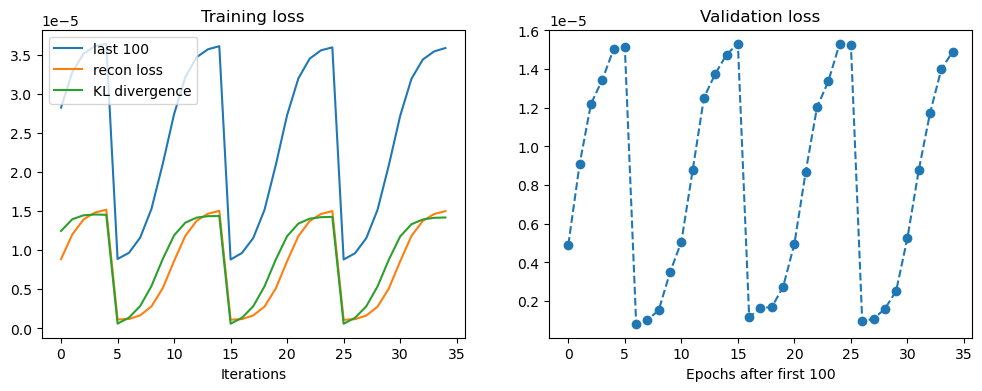

In [31]:
# PLOTTING LOSS
#plt.style.use('fivethirtyeight')
plt_split = 5

fig = plt.figure(figsize=(12,4))

# Plotting the last 100 values for training loss
ax1 = fig.add_subplot(1,2,1)
ax1.plot(losses_sum[plt_split:], label='last 100')
#ax1.plot(losses_sum[:plt_split], label='first 100')
ax1.plot(losses_1[plt_split:], label='recon loss')
ax1.plot(numpy.array(losses_2[plt_split:]), label='KL divergence')
ax1.set_xlabel('Iterations')
ax1.set_title('Training loss')
ax1.legend()

ax2 = fig.add_subplot(1,2,2)
ax2.plot(losses_val[plt_split:], '--o')
#ax2.plot(numpy.array(epoch_losses[-100:])/20, label='epoch-wise loss')
ax2.set_xlabel('Epochs after first 100')
ax2.set_title('Validation loss');
print(losses_1[-1], losses_2[-1], losses_sum[-1], losses_val[-1])

In [32]:
# Visualizing the latent space distribution - TEST DATA
inds = numpy.arange(len(test_data))

labels = test_data[:][1]
images = test_data[:][0]

#r_aux = labels[:, :3]

with torch.no_grad():
    
    # Creating reconstructions for test set
    r_new, _, _, z = VAE(images, labels, returnLatent=True)
    z_prior = numpy.random.multivariate_normal([0,0], [[1,0], [0,1]], len(inds))
    
    # generating samples
    
    generated = VAE.sample(labels, num_samples=len(labels))
    print(labels.shape, z.shape, generated.shape, r_new.shape, z_prior.shape)
 

torch.Size([39992, 6]) torch.Size([39992, 8]) torch.Size([39992, 3]) torch.Size([39992, 3]) (39992, 2)


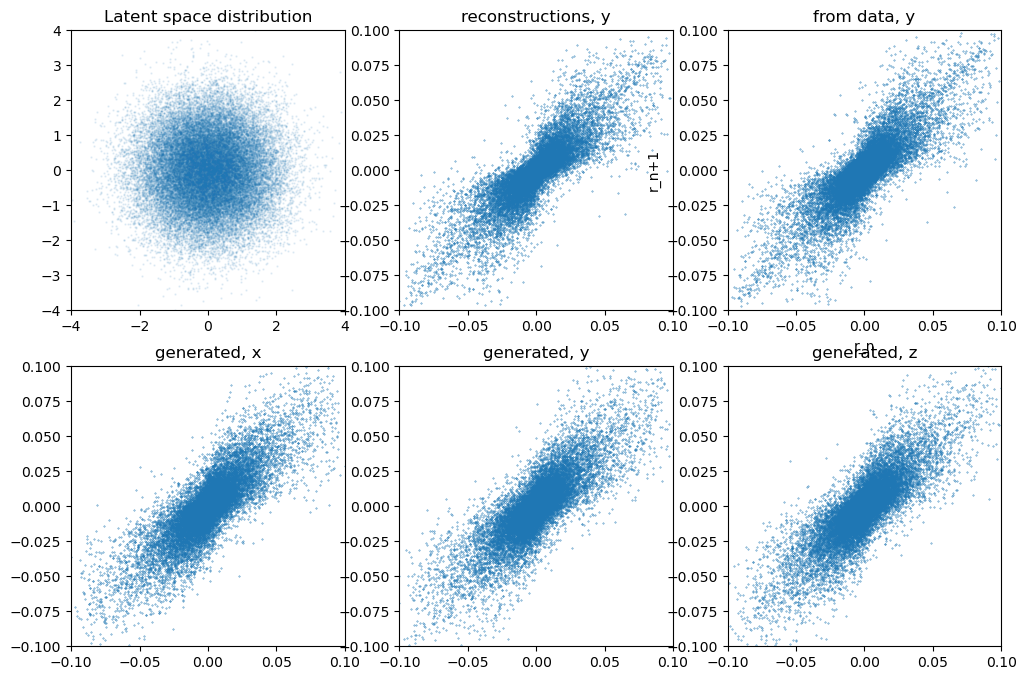

In [33]:
dim_labels = ['x', 'y', 'z']
dim_index = 1 # choose which dimension to plot
ax_lim = 0.1

fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(2,3,1)
ax1.scatter(z[inds, 0], z[inds, 1], s=0.5, alpha=0.1)
ax1.set_title('Latent space distribution')
ax1.set_xlim([-4,4])
ax1.set_ylim([-4,4])

ax2 = fig.add_subplot(2,3,2)
ax2.scatter(r_aux[inds, dim_index], r_new[inds, dim_index], s=0.1)
#ax2.scatter(z_prior[:,0], z_prior[:,1], s=0.5, alpha=0.2)
ax2.set_title(f'reconstructions, {dim_labels[dim_index]}')
ax2.set_xlim([-ax_lim, ax_lim])
ax2.set_ylim([-ax_lim, ax_lim])

ax3 = fig.add_subplot(2,3,3, sharex=ax2, sharey=ax2)
ax3.scatter(r_aux[inds, dim_index], r_nxt[inds, dim_index], s=0.1)
ax3.set_xlabel('r_n')
ax3.set_ylabel('r_n+1')
ax3.set_title(f'from data, {dim_labels[dim_index]}')

ax4 = fig.add_subplot(2,3,4, sharex=ax2, sharey=ax2)
ax4.scatter(r_aux[inds, 0], generated[inds, 0], s=0.1)
ax4.set_title('generated, x')

ax5 = fig.add_subplot(2,3,5, sharex=ax2, sharey=ax2)
ax5.scatter(r_aux[inds, 1], generated[inds, 1], s=0.1)
ax5.set_title('generated, y')

ax6 = fig.add_subplot(2,3,6, sharex=ax2, sharey=ax2)
ax6.scatter(r_aux[inds, 2], generated[inds, 2], s=0.1)
ax6.set_title('generated, z')

fig.show()

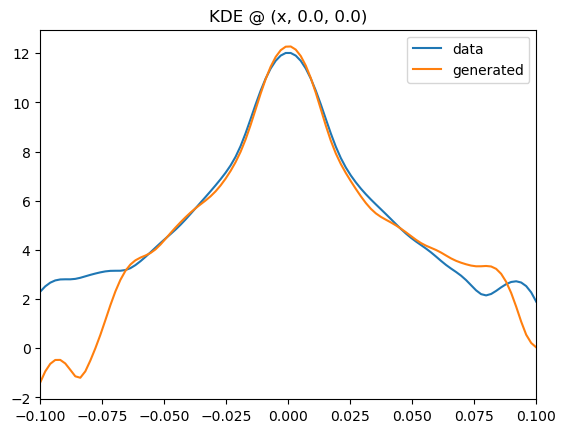

In [34]:
# Kernel Density Estimation - 3-dimensional fit (x,y,z)

# Original data
kde1 = KernelDensity(bandwidth=0.005)
kde1.fit(r_nxt)

# Generated data
kde2 = KernelDensity(bandwidth=0.005)
kde2.fit(generated);

# Reconstructed data - not particularly interesting (?)
#kde3 = KernelDensity(bandwidth=0.005)
#kde3.fit(r_new)

# Draw grid
num_gridpts = 100
grid_1d = numpy.linspace(-0.10, 0.10, num_gridpts)
c_yz = 0.0
E = numpy.full((num_gridpts,2), c_yz)
grid_slice = numpy.concatenate((grid_1d[:, numpy.newaxis], E), axis=1)

# Evaluate 3D KDE on grid
pdf_data = kde1.score_samples(grid_slice)
#pdf_rec = kde2.score_samples(grid_1d.reshape(-1,1))
pdf_gen = kde2.score_samples(grid_slice)

# Plotting 3D KDE evaluation at (x, 0, 0)
plt.plot(grid_slice[:,0], pdf_data, label='data')
#plt.plot(grid[:,0], pdf_rec, label='reconstructed')
plt.plot(grid_slice[:,0], pdf_gen, label='generated')
plt.title(f'KDE @ (x, {c_yz}, {c_yz})')
plt.xlim([-0.1, 0.1])
plt.legend()
plt.show()

#pdf_data

In [ ]:
#xv, yv, zv = numpy.meshgrid(grid_1d, grid_1d, grid_1d)
grid_reduced = numpy.linspace(-0.10, 0.10, 20)
grid_3d = numpy.array([[x, y, z] for x in grid_reduced for y in grid_reduced for z in grid_reduced])
grid_3d.shape, grid_slice.shape
pdf_data_3d = kde1.score_samples(grid_3d)
pdf_gen_3d = kde2.score_samples(grid_3d)

In [ ]:
plot_labels = ['data', 'generated']
plot_titles = ['KDE 1D - x', 'y', 'z']

fig = plt.figure(figsize=(14,4))

for i in range(len(plot_titles)):
    
    # Kernel Density Estimation - extracting 1 coordinate
    
    # Original data
    kde1_1d = KernelDensity(bandwidth=0.005)
    kde1_1d.fit(r_nxt[:, i].reshape(-1,1))
    
    # Generated data
    kde2_1d = KernelDensity(bandwidth=0.005)
    kde2_1d.fit(generated[:, i].reshape(-1,1));
    
    pdf_data_1d = kde1_1d.score_samples(grid_1d.reshape(-1,1))
    pdf_gen_1d = kde2_1d.score_samples(grid_1d.reshape(-1,1))

    ax = fig.add_subplot(1, 3, i+1)
    ax.plot(grid_1d, pdf_data_1d, label = 'data')
    ax.plot(grid_1d, pdf_gen_1d, label = 'generated')
    ax.set_title(plot_titles[i])
    ax.legend()

fig.show()

In [ ]:
print("Wasserstein Distance")
wasserstein_distance_nd(pdf_data_3d, pdf_gen_3d)

## plot_this = True # <==3


if plot_this:

    fig = plt.figure(figsize=(12,8))
    
    ax1 = fig.add_subplot(2,3,1)
    ax1.scatter(r_aux[inds, dim_index], r_nxt[inds, dim_index], s=0.1)
    ax1.set_xlabel('r_n')
    ax1.set_ylabel('r_n+1')
    ax1.set_title('from data')
    ax1.set_xlim([-0.1,0.1])
    ax1.set_ylim([-0.1,0.1])
    
    ax2 = fig.add_subplot(2,3,2, sharex=ax1, sharey=ax1)
    ax2.scatter(r_aux[inds, dim_index], r_new[inds, dim_index], s=0.1)
    ax2.set_xlabel('r_n')
    ax2.set_ylabel('r_n+1')
    ax2.set_title('from reconstruction')
    
    ax3 = fig.add_subplot(2,3,3, sharex=ax1, sharey=ax1)
    ax3.scatter(r_aux[inds, dim_index], generated[inds, dim_index], s=0.1)
    ax3.set_xlabel('r_n')
    ax3.set_ylabel('r_n+1')
    ax3.set_title('generated')
    
    ax4 = fig.add_subplot(2,3,4, sharey=ax1)
    ax4.scatter(v[inds, dim_index], r_nxt[inds, dim_index], s=0.1)
    ax4.set_xlabel('v_n')
    ax4.set_ylabel('r_n+1')
    ax4.set_xlim([-0.5,0.5])
    
    ax5 = fig.add_subplot(2,3,5, sharex=ax4, sharey=ax1)
    ax5.scatter(v[inds, dim_index], r_new[inds, dim_index], s=0.1)
    ax5.set_xlabel('v_n')
    ax5.set_ylabel('r_n+1')
    
    ax6 = fig.add_subplot(2,3,6, sharex=ax4, sharey=ax1)
    ax6.scatter(v[inds, dim_index], generated[inds, dim_index], s=0.1)
    ax6.set_xlabel('v_n')
    ax6.set_ylabel('r_n+1')
    
    fig.show()

In [19]:
# Save model parameters
save_model = False
if save_model==True:
    model_name = 'model_state_piri_FS4.pt'
    torch.save(VAE.state_dict(), 'modelWeights/' + model_name)
    print(f'Model parameters saved under "{model_name}"')

Text(0.5, 1.0, 'Latent space distribution')

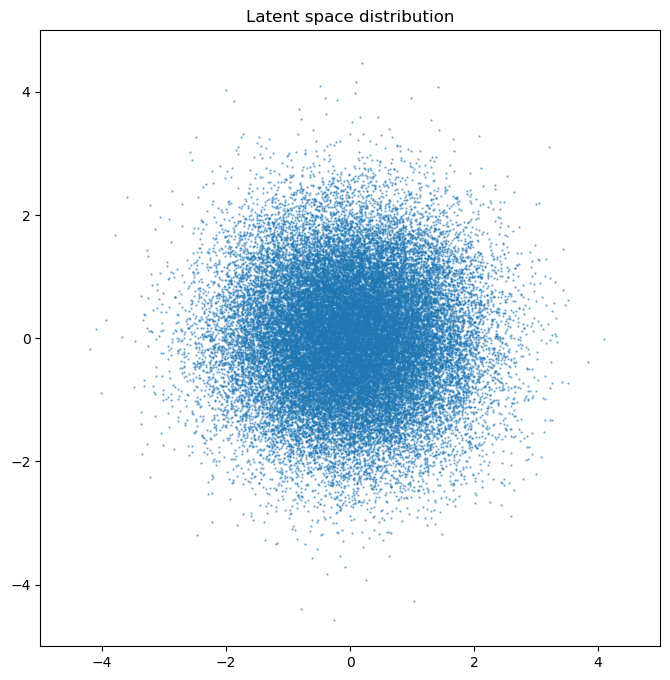

In [20]:
plt.figure(figsize=(8,8))
plt.scatter(z[inds, 0], z[inds, 1], s=0.5, alpha=0.5)
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.title('Latent space distribution')

In [32]:
# This cell will take a few models and average their state-dicts.

# List of models to be taken in the average.
model_names = ['E81', 'E82', 'E83', 'E84', 'E85']

conditionedOn = 'piri'
localFP = 'modelWeights/' + 'model_state_' + conditionedOn + '_'
model_paths = [localFP + name + '.pt' for name in model_names]

models_to_avg = [VarAutoencoder_SE(8, loadPretrained, conditionedOn).state_dict() for loadPretrained in model_paths]

sdOut = models_to_avg[0]

# Average all parameters
for key in sdOut:
    for sdM in models_to_avg:
        sdOut[key] = (sdOut[key] + sdM[key])
    sdOut[key] = sdOut[key]/len(models_to_avg)

# Recreate model and load averaged state_dict (or use modelA/B)
modelA = VarAutoencoder_SE(8, None, conditionedOn)
modelA.load_state_dict(sdOut)

save_averaged_model=False
if save_averaged_model:
    model_name = 'model_state_piri_E8A.pt'
    torch.save(modelA.state_dict(), 'modelWeights/' + model_name)
    print(f'Model parameters saved under "{model_name}"')

Loading pretrained model: modelWeights/model_state_piri_E81.pt
Model parameters loaded.
Loading pretrained model: modelWeights/model_state_piri_E82.pt
Model parameters loaded.
Loading pretrained model: modelWeights/model_state_piri_E83.pt
Model parameters loaded.
Loading pretrained model: modelWeights/model_state_piri_E84.pt
Model parameters loaded.
Loading pretrained model: modelWeights/model_state_piri_E85.pt
Model parameters loaded.
Untrained model initialized. S. CondtionedVars:  piri
